<a href="https://colab.research.google.com/github/oluchiokoro-debug/colab-git-assignment2-OO/blob/main/sson_8_Supervised_Classification_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = sns.load_dataset("titanic")
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [3]:
print(df.shape)
df.info()
df.isnull().sum()

(891, 15)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


,0
survived,0
pclass,0
sex,0
age,177
sibsp,0
parch,0
fare,0
embarked,2
class,0
who,0


In [4]:
# Fill missing values
df['age'].fillna(df['age'].median(), inplace=True)
df['embarked'].fillna(df['embarked'].mode()[0], inplace=True)

# Drop cabin (too many missing values)
df.drop('deck', axis=1, inplace=True)

# Drop rows with remaining nulls
df.dropna(inplace=True)

df.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,0
sibsp,0
parch,0
fare,0
embarked,0
class,0
who,0


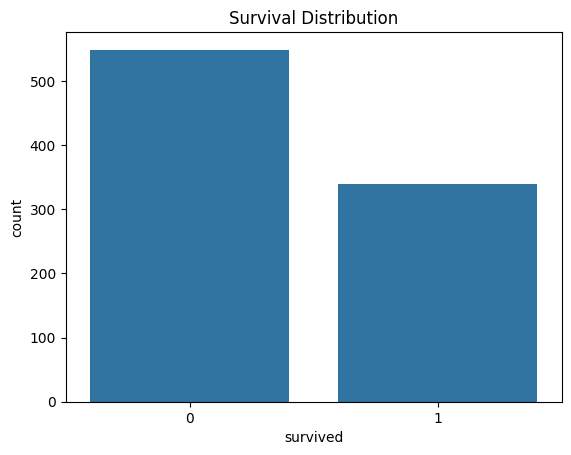

In [5]:
sns.countplot(x='survived', data=df)
plt.title("Survival Distribution")
plt.show()

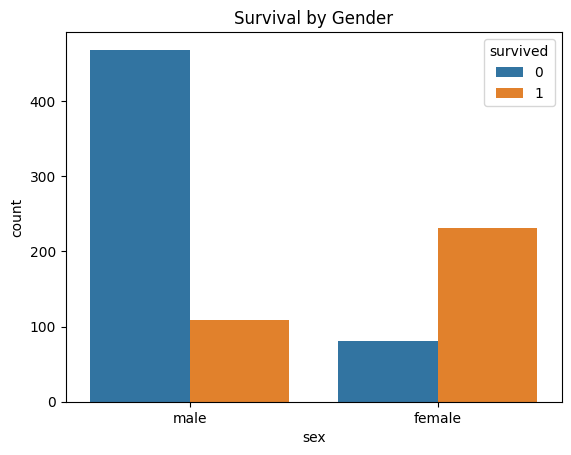

In [6]:
sns.countplot(x='sex', hue='survived', data=df)
plt.title("Survival by Gender")
plt.show()

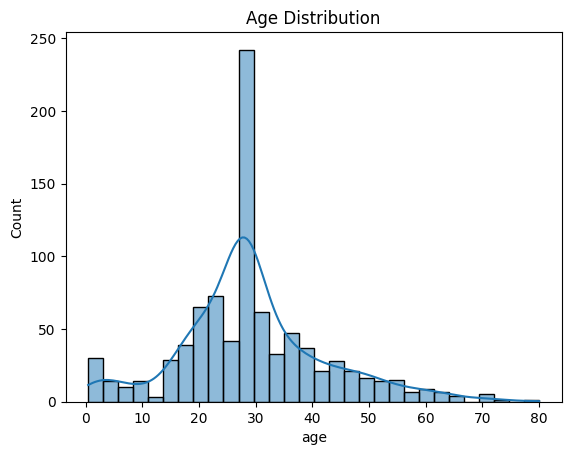

In [7]:
sns.histplot(df['age'], bins=30, kde=True)
plt.title("Age Distribution")
plt.show()

In [8]:
le = LabelEncoder()

df['sex'] = le.fit_transform(df['sex'])
df['embark_town'] = le.fit_transform(df['embark_town'])
df['class'] = le.fit_transform(df['class'])

In [9]:
df_model = df[['survived', 'pclass', 'sex', 'age', 'fare', 'embark_town']]

X = df_model.drop('survived', axis=1)
y = df_model['survived']

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [11]:
lr = LogisticRegression()
lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)
lr_prob = lr.predict_proba(X_test)[:,1]

In [12]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)
rf_prob = rf.predict_proba(X_test)[:,1]

In [13]:
def evaluate_model(name, y_test, pred, prob):
    print(f"\n{name} Results")
    print("Accuracy:", accuracy_score(y_test, pred))
    print("Precision:", precision_score(y_test, pred))
    print("Recall:", recall_score(y_test, pred))
    print("F1 Score:", f1_score(y_test, pred))
    print("ROC AUC:", roc_auc_score(y_test, prob))
    print("\nClassification Report:\n", classification_report(y_test, pred))

In [14]:
evaluate_model("Logistic Regression", y_test, lr_pred, lr_prob)
evaluate_model("Random Forest", y_test, rf_pred, rf_prob)


Logistic Regression Results
Accuracy: 0.7752808988764045
Precision: 0.6933333333333334
Recall: 0.7536231884057971
F1 Score: 0.7222222222222222
ROC AUC: 0.8500864246775695

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.79      0.81       109
           1       0.69      0.75      0.72        69

    accuracy                           0.78       178
   macro avg       0.76      0.77      0.77       178
weighted avg       0.78      0.78      0.78       178


Random Forest Results
Accuracy: 0.8089887640449438
Precision: 0.7272727272727273
Recall: 0.8115942028985508
F1 Score: 0.7671232876712328
ROC AUC: 0.8649115809067943

Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.81      0.84       109
           1       0.73      0.81      0.77        69

    accuracy                           0.81       178
   macro avg       0.80      0.81      0.80       178
weighted avg 

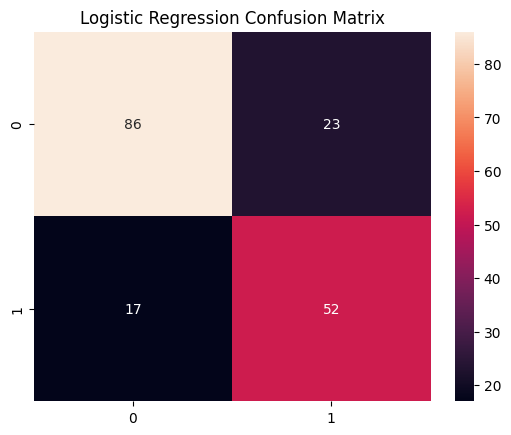

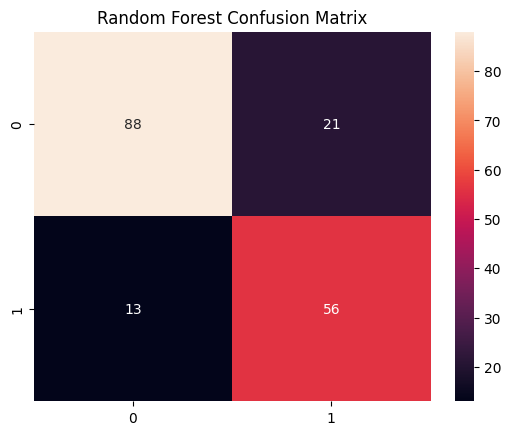

In [15]:
sns.heatmap(confusion_matrix(y_test, lr_pred), annot=True, fmt='d')
plt.title("Logistic Regression Confusion Matrix")
plt.show()

sns.heatmap(confusion_matrix(y_test, rf_pred), annot=True, fmt='d')
plt.title("Random Forest Confusion Matrix")
plt.show()

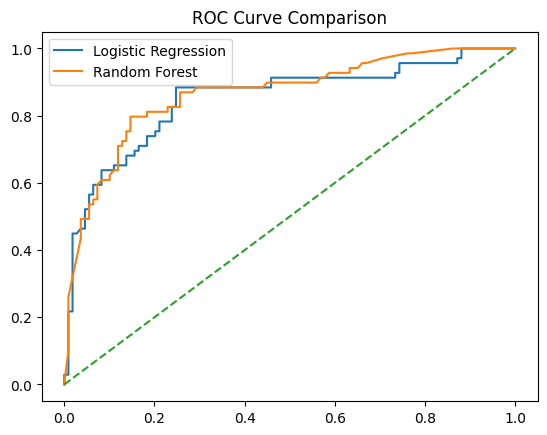

In [16]:
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_prob)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_prob)

plt.plot(lr_fpr, lr_tpr, label="Logistic Regression")
plt.plot(rf_fpr, rf_tpr, label="Random Forest")
plt.plot([0,1],[0,1],'--')

plt.legend()
plt.title("ROC Curve Comparison")
plt.show()

In [17]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, rf_pred)
    ]
})

results

,Model,Accuracy
0,Logistic Regression,0.775281
1,Random Forest,0.808989


In [18]:
best = results.loc[results['Accuracy'].idxmax()]
print("Best Model:\n", best)

Best Model:
 Model       Random Forest
Accuracy         0.808989
Name: 1, dtype: object
